© 2026 WaLSA Team - Shahin Jafarzadeh et al.

This notebook is part of the [WaLSAlib](https://github.com/WaLSAteam/WaLSAlib) package (v1.0.0), provided under the [Apache License, Version 2.0](http://www.apache.org/licenses/LICENSE-2.0).

You may use, modify, and distribute this notebook and its contents under the terms of the license.

---

**Important Note on Figures**:
Figures generated using this notebook that are **identical to or derivative of those published in**:  
**Jafarzadeh, S., Jess, D. B., Stangalini, M. et al. 2026, *Frontiers in Astronomy and Space Sciences*, in press**,  
as part of the research topic: **[Magnetohydrodynamic Motions: Daniel K. Inouye Solar Telescope’s Window into the Dynamic Sun](https://www.frontiersin.org/research-topics/71781/magnetohydrodynamic-motions-daniel-k-inouye-solar-telescopes-window-into-the-dynamic-sun)**,    
are copyrighted by ***Frontiers in Astronomy and Space Sciences***. Any reuse of such figures requires explicit permission from the journal.   

Figures that are newly created, modified, or unrelated to the published article may be used under the terms of the Apache License.

---

**Disclaimer**:
This notebook and its code are provided "as is", without warranty of any kind, express or implied. Refer to the license for more details.

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Figure 4 — Calculations
=========================

Purpose
-------
Compute and cache all velocity time series used by Figure 4:

  • Truth velocities                      v_true(t)
  • LineFit velocities                    v_linefit(t)   (computed here OR loaded)
  • Fast estimators (per time step):
      - Parabolic minimum                 v_parab(t)
      - Centre-of-gravity (COG)           v_cog(t)
      - Fourier-phase centroid (k=1)      v_fft(t)
      - Weighted polynomial core fit      v_poly(t)    ("Poly6w")

This script writes NumPy cache files to `Files/Fig4_cache/` that are then consumed by
the plotting script (Figure 4 — Plot).

Key design choices (paper consistency)
--------------------------------------
• The four fast estimators use the same logic as Figure 3, applied to the full time series:
    - close-pair-safe coarse localisation per time step (valley split for close_pairs)
    - per-line half windows: per_line_window_size[i] (matches Figure 3)
    - FFT-phase centroid: identical implementation to Figure 3
    - Poly6w: identical implementation to Figure 3
• LineFit velocities can be:
    (A) computed locally (simple, single-machine; not parallelised), OR
    (B) loaded from a consolidated file `Files/Fig4_cache/v_linefit.npy`
        (shape (nt,10) or (10,nt))

Inputs
------
Required:
  - synthetic_nuv_testbed.fits

Optional (choose one LineFit path):
  - Files/Fig4_cache/v_linefit.npy (consolidated; shape (nt,10) or (10,nt)), OR
  - local execution of LineFit over the full cube (slow but simple)

Outputs
-------
Writes to `Files/Fig4_cache/`:
  - fig4_vtimeseries__t_s.npy
  - fig4_vtimeseries__lambda0_nm.npy
  - fig4_vtimeseries__v_true.npy
  - fig4_vtimeseries__v_linefit.npy
  - fig4_vtimeseries__v_parab.npy
  - fig4_vtimeseries__v_cog.npy
  - fig4_vtimeseries__v_fft.npy
  - fig4_vtimeseries__v_poly.npy
  - fig4_vtimeseries__meta.npz

Authors
-------
  WaLSA Team / Shahin Jafarzadeh (2026)
  https://WaLSA.team

License
-------
  Apache-2.0 license — see LICENSE file in the WaLSAlib repository.
  https://github.com/WaLSAteam/WaLSAlib

"""

from __future__ import annotations

import os
import time
import json
import numpy as np
from astropy.io import fits

from scipy.ndimage import uniform_filter1d
from scipy.signal import find_peaks

from WaLSAlib import linefit   # type: ignore
from WaLSAtools import WaLSAtools, WaLSA_save_pdf  # type: ignore

# =============================================================================
# USER SETTINGS (MUST match Figure 3)
# =============================================================================
FITS_PATH = "synthetic_nuv_testbed.fits"

# Representative lines for the plotting stage (stored in meta; plot script uses them)
i_clean = 0   # isolated symmetric absorption
i_asym  = 2   # asymmetric-from-core / blended
i_comp  = 5   # split-core / emission-reversal candidate

# Close pairs (synthetic: lines 4–5 in 1-based => (3,4) in 0-based)
close_pairs = [(3, 4)]

# Per-line half-window in pixels (MUST match Figure 3)
per_line_window_size = [10, 10, 10, 10, 10, 28, 18, 10, 10, 20]

# -----------------------------------------------------------------------------
# Directory structure (requested)
# -----------------------------------------------------------------------------
FILES_DIR = "Files"
CACHE_DIR = os.path.join(FILES_DIR, "Fig4_cache")
CACHE_TAG = "fig4_vtimeseries"

# -----------------------------------------------------------------------------
# How to obtain v_linefit (LineFit full time series)
# Choose ONE:
#   "compute_local"  -> run LineFit here on the full cube
#   "load_npy"       -> load Files/Fig4_cache/v_linefit.npy (consolidated)
# -----------------------------------------------------------------------------
LINEFIT_MODE = "compute_local"  # <-- OPTIONS: "compute_local" / "load_npy"
V_LINEFIT_NPY = os.path.join(CACHE_DIR, "v_linefit.npy")  # used when LINEFIT_MODE="load_npy"

# -----------------------------------------------------------------------------
# LineFit timing (compute runtime only; avoids full-series LineFit)
# -----------------------------------------------------------------------------
MEASURE_LINEFIT_RUNTIME = True      # set False to disable timing
LINEFIT_TIMING_NFRAMES = 10         # number of time steps to run LineFit on for timing 
LINEFIT_TIMING_SEED = 7
LINEFIT_TIMING_STRATEGY = "uniform" # "uniform" or "random"
SAVE_LINEFIT_TIMING_JSON = True

# LineFit parameters (matching the paper settings)
NUM_ITERATIONS   = 20
WINDOW_SIZE      = 14
SMOOTHING_WINDOW = 1

PER_LINE_MIN_HALFWIN = [8, 10, 8, 8, 8, 14, 10, 8, 8, 12]
PER_LINE_MAX_HALFWIN = [14, 13, 12, 12, 12, 36, 22, 14, 12, 24]

USE_COARSE_CENTERS  = True
ADAPTIVE_WINDOW     = True
WRITE_CSV           = True
SAVE_FITTED_SPECTRA = True
PLOT_RESULT         = False
SILENT              = True

REVERSAL_LINES = [5]  # 0-based index for split/reversal line

# Constants
C_KMS = 299792.458


# =============================================================================
# Figure-3 helper functions (copied verbatim in behaviour)
# =============================================================================
def local_continuum_estimate(y):
    """Robust local continuum estimate from top 20% of samples in the window."""
    y = np.asarray(y, float)
    if y.size == 0 or np.all(~np.isfinite(y)):
        return np.nan
    y = y[np.isfinite(y)]
    if y.size == 0:
        return np.nan
    top = np.sort(y)[int(0.8 * len(y)):]
    return np.median(top) if top.size else np.max(y)


def extract_parabolic_min_robust(wl, I, idx0, half_win=16, max_recenter=2):
    """
    Parabolic minimum estimator:
      1) find local minimum in a window (with limited recentering)
      2) fit quadratic to 3 points around the minimum
      3) return vertex position (-b/2a) in nm
    """
    wl = np.asarray(wl, float)
    I  = np.asarray(I, float)
    n = wl.size

    center = int(idx0)

    for _ in range(max_recenter + 1):
        lo = max(0, center - half_win)
        hi = min(n, center + half_win + 1)
        x = wl[lo:hi]
        y = I[lo:hi]

        if np.any(~np.isfinite(y)):
            m = np.nanmedian(y)
            if not np.isfinite(m):
                return np.nan
            y = np.where(np.isfinite(y), y, m)

        j = int(np.argmin(y))

        if j <= 0 or j >= (y.size - 1):
            center = lo + j
            continue

        x3 = x[j-1:j+2]
        y3 = y[j-1:j+2]
        a, b, c = np.polyfit(x3, y3, 2)
        if (not np.isfinite(a)) or abs(a) < 1e-30:
            return np.nan
        return -b / (2*a)

    return np.nan


def extract_cog(wl, I, idx0, half_win=26):
    """
    Standard COG of absorption depression:
      D = 1 - I/Ic  (clipped to >= 0)
      center = sum(wl * D) / sum(D)
    """
    wl = np.asarray(wl, float)
    I  = np.asarray(I, float)
    n = wl.size
    lo = max(0, idx0 - half_win)
    hi = min(n, idx0 + half_win + 1)
    x = wl[lo:hi]
    y = I[lo:hi]

    Ic = local_continuum_estimate(y)
    if not np.isfinite(Ic) or Ic <= 0:
        return np.nan

    D = 1.0 - (y / Ic)
    D = np.clip(D, 0.0, None)
    denom = np.sum(D)
    if denom <= 0 or not np.isfinite(denom):
        return np.nan

    return np.sum(x * D) / denom


def nearest_index(w, x):
    """Nearest index of wavelength array w to target wavelength x."""
    return int(np.argmin(np.abs(np.asarray(w, float) - float(x))))


def _fft_phase_position_index(profile, prefer_center=True):
    """
    Reference-free k=1 phase position in index units.
    profile: 1D array (window)
    Returns fractional index in [0, N) (or near center if prefer_center=True).
    """
    p = np.asarray(profile, float)
    N = p.size
    if N < 8 or (not np.isfinite(p).all()):
        return np.nan

    # remove DC so the k=1 phase reflects where the "bump" is
    p = p - np.mean(p)

    F1 = np.fft.fft(p.astype(np.float64))[1]
    if np.abs(F1) < 1e-20:
        return np.nan

    # correct mapping for delta-like bump: angle(F1) = -2π n0/N
    pos = (-N / (2.0 * np.pi)) * np.angle(F1)

    # wrap to [0, N)
    pos = float(np.mod(pos, N))

    if prefer_center:
        mid = 0.5 * (N - 1)
        candidates = np.array([pos, pos + N, pos - N], float)
        pos = float(candidates[np.argmin(np.abs(candidates - mid))])

    return pos


def extract_fourier_phase_center_single(
    wl, I, idx0,
    wl_ref=None, I_ref=None, idx0_ref=None,
    half_win=30,
    apodize=True,
    x0_ref_center_nm=None,
):
    """
    FFT-phase centroid:
      - estimate local continuum Ic
      - build absorption depression D = 1 - I/Ic (>=0)
      - optionally apodize D with Hanning
      - compute k=1 FFT phase position -> convert to wavelength
    """
    wl = np.asarray(wl, float)
    I  = np.asarray(I, float)
    n = wl.size

    lo = max(0, int(idx0) - int(half_win))
    hi = min(n, int(idx0) + int(half_win) + 1)
    x = wl[lo:hi]
    y = I[lo:hi]

    if x.size < 10 or y.size != x.size:
        return np.nan

    if np.any(~np.isfinite(y)):
        m = np.nanmedian(y)
        if not np.isfinite(m):
            return np.nan
        y = np.where(np.isfinite(y), y, m)

    Ic = local_continuum_estimate(y)
    if (not np.isfinite(Ic)) or Ic <= 0:
        return np.nan

    D = 1.0 - (y / Ic)
    D = np.clip(D, 0.0, None)
    if (not np.isfinite(D).all()) or np.sum(D) <= 0:
        return np.nan

    if apodize:
        D = D * np.hanning(D.size)

    pos = _fft_phase_position_index(D, prefer_center=True)
    if not np.isfinite(pos):
        return np.nan

    step = float(x[1] - x[0])
    return float(x[0] + pos * step)


def extract_polycore_weighted(
    wl,
    I,
    idx0,
    *,
    N=7,
    poly_order=6,
    max_recenter=2,
    weight_eps=0.1,
    return_intensity=True,
):
    """
    Weighted polynomial core fit:
      - find local minimum with limited recentering
      - fit polynomial of given order around the minimum (shifted coordinates)
      - weights favour points near the minimum (1/(eps+|Δλ|))
      - find minimum of polynomial (via roots of derivative + edge checks)
    """
    wl = np.asarray(wl, float)
    I = np.asarray(I, float)
    n = wl.size
    if n < 5:
        return (np.nan, np.nan) if return_intensity else np.nan

    center = int(idx0)

    for _ in range(max_recenter + 1):
        half_win = max(int(N) + 2, 6)
        lo = max(0, center - half_win)
        hi = min(n, center + half_win + 1)

        xw = wl[lo:hi]
        yw = I[lo:hi]

        if xw.size < (2 * N + 1):
            return (np.nan, np.nan) if return_intensity else np.nan

        if np.any(~np.isfinite(yw)):
            m = np.nanmedian(yw)
            if not np.isfinite(m):
                return (np.nan, np.nan) if return_intensity else np.nan
            yw = np.where(np.isfinite(yw), yw, m)

        j_local = int(np.argmin(yw))
        idx_min = lo + j_local

        if j_local <= 0 or j_local >= (yw.size - 1):
            center = idx_min
            continue

        lo2 = max(0, idx_min - int(N))
        hi2 = min(n, idx_min + int(N) + 1)

        x = wl[lo2:hi2]
        y = I[lo2:hi2]

        if x.size < (poly_order + 1):
            return (np.nan, np.nan) if return_intensity else np.nan

        if np.any(~np.isfinite(y)):
            m = np.nanmedian(y)
            if not np.isfinite(m):
                return (np.nan, np.nan) if return_intensity else np.nan
            y = np.where(np.isfinite(y), y, m)

        x_min = float(wl[idx_min])
        w = 1.0 / (float(weight_eps) + np.abs(x - x_min))
        if not np.isfinite(w).all():
            return (np.nan, np.nan) if return_intensity else np.nan
        w = w / (np.nanmax(w) + 1e-30)

        x_shift = x - x_min
        try:
            coeffs = np.polyfit(x_shift, y, int(poly_order), w=w)
        except Exception:
            return (np.nan, np.nan) if return_intensity else np.nan

        if not np.isfinite(coeffs).all():
            return (np.nan, np.nan) if return_intensity else np.nan

        dcoeffs = np.polyder(coeffs)
        roots = np.roots(dcoeffs)

        r = roots[np.isreal(roots)].real
        xmin_s = float(np.min(x_shift))
        xmax_s = float(np.max(x_shift))
        r = r[(r >= xmin_s) & (r <= xmax_s)]

        candidates = np.r_[r, xmin_s, xmax_s]
        pvals = np.polyval(coeffs, candidates)
        if pvals.size == 0 or np.all(~np.isfinite(pvals)):
            return (np.nan, np.nan) if return_intensity else np.nan

        k = int(np.nanargmin(pvals))
        x_best_shift = float(candidates[k])
        center_nm = float(x_min + x_best_shift)

        if not return_intensity:
            return center_nm

        I_center = float(np.polyval(coeffs, x_best_shift))
        return center_nm, I_center

    return (np.nan, np.nan) if return_intensity else np.nan


def coarse_centers_closepair_safe(
    wl, I, lambda0_nm,
    search_half_win=120,
    smooth=3,
    close_pairs=[(3, 4)],
    peak_distance=2,
    height_rel=0.05,
    valley_pad_bins=0,
):
    """
    Coarse localisation of each line minimum starting from the rest wavelengths lambda0_nm.
    For close pairs, split “ownership” by the inter-line valley to prevent swapping.
    """
    wl = np.asarray(wl, float)
    I  = np.asarray(I, float)
    lam0 = np.asarray(lambda0_nm, float)
    nlines = lam0.size
    n = wl.size

    y = np.nan_to_num(I, nan=np.nanmedian(I) if np.any(np.isfinite(I)) else 0.0)
    y01 = (y - np.min(y)) / (np.max(y) - np.min(y) + 1e-12)
    sm = uniform_filter1d(y01, size=int(smooth))
    inv = 1.0 - sm

    def pick_peak_in_interval(i, lo, hi):
        lo = int(max(0, lo))
        hi = int(min(n - 1, hi))
        if hi <= lo + 4:
            return int(np.clip(nearest_index(wl, lam0[i]), lo, hi))

        seg = inv[lo:hi+1]
        if seg.size < 10 or (not np.isfinite(seg).all()):
            return int(lo + np.nanargmax(seg))

        thr = float(height_rel * np.nanmax(seg))
        pks, _props = find_peaks(seg, distance=int(peak_distance), height=thr)
        if pks.size == 0:
            return int(lo + np.nanargmax(seg))

        pks_abs = lo + pks
        dist = np.abs(wl[pks_abs] - lam0[i])
        height = inv[pks_abs]
        score = dist + 0.10 * (1.0 - height / (np.nanmax(height) + 1e-12))
        return int(pks_abs[np.argmin(score)])

    idx = np.full(nlines, -1, dtype=int)
    for i in range(nlines):
        idx0 = nearest_index(wl, lam0[i])
        lo = max(0, idx0 - int(search_half_win))
        hi = min(n - 1, idx0 + int(search_half_win))
        idx[i] = pick_peak_in_interval(i, lo, hi)

    for (i, j) in close_pairs:
        ii = nearest_index(wl, lam0[i])
        jj = nearest_index(wl, lam0[j])
        a = min(ii, jj)
        b = max(ii, jj)

        if b <= a + 2:
            valley = (a + b) // 2
        else:
            seg = inv[a:b+1]
            valley = int(a + np.argmin(seg))

        valley_L = max(0, valley - int(valley_pad_bins))
        valley_R = min(n - 1, valley + int(valley_pad_bins))

        lo_pair = max(0, a - int(search_half_win))
        hi_pair = min(n - 1, b + int(search_half_win))

        idx[i] = pick_peak_in_interval(i, lo_pair, valley_L)
        idx[j] = pick_peak_in_interval(j, valley_R, hi_pair)

    centers_nm = wl[idx].astype(float)
    return centers_nm, idx


# =============================================================================
# Load synthetic testbed FITS
# =============================================================================
with fits.open(FITS_PATH) as hdul:
    spectra     = np.asarray(hdul[0].data)                  # (nt, nw)
    wavelengths = np.asarray(hdul["WAVELENGTH"].data)       # (nw,)
    time_s      = np.asarray(hdul["TIME"].data)             # (nt,)
    lambda0_nm  = np.asarray(hdul["LAMBDA0"].data)          # (10,)
    v_true_kms  = np.asarray(hdul["V_TRUE"].data)           # (10, nt)

nt, nw = spectra.shape
n_lines = int(lambda0_nm.size)
if n_lines != 10:
    raise ValueError(f"Expected 10 lines; got {n_lines}")


# =============================================================================
# Obtain v_true as (nt, 10)
# =============================================================================
v_true = np.asarray(v_true_kms, float)
if v_true.shape == (n_lines, nt):
    v_true = v_true.T
elif v_true.shape != (nt, n_lines):
    raise ValueError(f"Unexpected v_true_kms shape: {v_true.shape}")

# Choose representative time indices for timing (if enabled)
def pick_time_indices_for_timing(nt: int, nframes: int, seed: int, strategy: str = "uniform") -> np.ndarray:
    nframes = int(min(max(nframes, 1), nt))
    if strategy == "uniform":
        return np.unique(np.round(np.linspace(0, nt - 1, nframes)).astype(int))
    if strategy == "random":
        rng = np.random.default_rng(int(seed))
        return np.sort(rng.choice(nt, size=nframes, replace=False))
    raise ValueError(f"Unknown LINEFIT_TIMING_STRATEGY={strategy!r}")

# =============================================================================
# Obtain v_linefit as (nt, 10)
# =============================================================================
def _coerce_v_to_nt10(v_in: np.ndarray, nt: int, n_lines: int) -> np.ndarray:
    """Accept (nt,10) or (10,nt) and return (nt,10)."""
    v = np.asarray(v_in, float)
    if v.shape == (n_lines, nt):
        return v.T
    if v.shape == (nt, n_lines):
        return v
    raise ValueError(f"Unexpected v shape {v.shape}; expected ({nt},{n_lines}) or ({n_lines},{nt}).")


def load_v_linefit_consolidated(path: str, nt: int, n_lines: int) -> np.ndarray:
    v = np.load(path)
    return _coerce_v_to_nt10(v, nt=nt, n_lines=n_lines)


def compute_v_linefit_local(
    spectra: np.ndarray,
    wavelengths: np.ndarray,
    lambda0_nm: np.ndarray,
    time_indices: Optional[np.ndarray] = None,   # NEW
) -> Tuple[np.ndarray, float]:                   # NEW
    """
    LineFit execution.
    If time_indices is provided, LineFit is run ONLY on those time steps (for timing).
    Returns: (v_out, elapsed_seconds).
    """
    element       = np.array([f"Line {i}" for i in range(10)], dtype=object)
    refwavelength = lambda0_nm.copy()

    pix = None
    if time_indices is not None:
        pix = np.asarray(time_indices, dtype=int)

    t0 = time.perf_counter()
    v_out, _i_out = linefit(
        spectra               = np.asarray(spectra, dtype=np.float64),
        fit_func              = "asymmetric_voigt",
        num_iterations        = NUM_ITERATIONS,
        date_identifier       = "linefit_fullseries_local" if pix is None else "linefit_subset_timing",
        refwavelength         = refwavelength,
        wavelengths           = np.asarray(wavelengths, dtype=np.float64),
        element               = element,
        pixel                 = pix,
        window_size           = WINDOW_SIZE,
        per_line_window_size  = per_line_window_size,
        per_line_min_halfwin  = PER_LINE_MIN_HALFWIN,
        per_line_max_halfwin  = PER_LINE_MAX_HALFWIN,
        plot_result           = PLOT_RESULT,
        smoothing_window      = SMOOTHING_WINDOW,
        return_vlos_intensity = True,
        adaptive_window       = ADAPTIVE_WINDOW,
        write_csv             = WRITE_CSV,
        save_fitted_spectra   = SAVE_FITTED_SPECTRA,
        use_coarse_centers    = USE_COARSE_CENTERS,
        close_pairs           = close_pairs,
        reversal_lines        = REVERSAL_LINES,
        silent                = SILENT,
    )
    elapsed = float(time.perf_counter() - t0)

    v_out = np.asarray(v_out, float)

    # If subset timing, do NOT coerce to (nt,10) (it won't match nt)
    if pix is not None:
        return v_out, elapsed

    return _coerce_v_to_nt10(v_out, nt=nt, n_lines=n_lines), elapsed


if LINEFIT_MODE == "load_npy":
    if not os.path.exists(V_LINEFIT_NPY):
        raise FileNotFoundError(
            f"LINEFIT_MODE='load_npy' but file not found:\n  {V_LINEFIT_NPY}\n"
            "Either place v_linefit.npy there, or set LINEFIT_MODE='compute_local'."
        )
    v_linefit = load_v_linefit_consolidated(V_LINEFIT_NPY, nt=nt, n_lines=n_lines)

elif LINEFIT_MODE == "compute_local":
    v_linefit, _t_full = compute_v_linefit_local(
        spectra=spectra, wavelengths=wavelengths, lambda0_nm=lambda0_nm, time_indices=None
    )
    # Save a consolidated LineFit product for reuse (when "load_npy" is chosen in the future)
    os.makedirs(CACHE_DIR, exist_ok=True)
    np.save(V_LINEFIT_NPY, v_linefit)
    print("Saved consolidated LineFit velocities to:", V_LINEFIT_NPY)

# =============================================================================
# Measure LineFit runtime ONLY (subset timing + scaling)
# =============================================================================
linefit_timing = None
if MEASURE_LINEFIT_RUNTIME:
    idx_time = pick_time_indices_for_timing(
        nt=nt,
        nframes=LINEFIT_TIMING_NFRAMES,
        seed=LINEFIT_TIMING_SEED,
        strategy=LINEFIT_TIMING_STRATEGY,
    )

    _v_tmp, t_subset_s = compute_v_linefit_local(
        spectra=spectra,
        wavelengths=wavelengths,
        lambda0_nm=lambda0_nm,
        time_indices=idx_time,
    )

    per_frame_s = t_subset_s / max(int(len(idx_time)), 1)
    total_est_s = per_frame_s * float(nt)

    linefit_timing = {
        "timed_frames": int(len(idx_time)),
        "nt_total": int(nt),
        "strategy": str(LINEFIT_TIMING_STRATEGY),
        "seed": int(LINEFIT_TIMING_SEED),
        "subset_runtime_s": float(t_subset_s),
        "per_frame_s_mean": float(per_frame_s),
        "total_estimated_s": float(total_est_s),
    }

    print("\n--- LineFit runtime (subset timing) ---")
    print(f"Timed frames: {len(idx_time)}/{nt}  strategy={LINEFIT_TIMING_STRATEGY}")
    print(f"Subset runtime: {t_subset_s:.3f} s")
    print(f"Mean per time step: {per_frame_s:.6f} s")
    print(f"Estimated full-series LineFit runtime: {total_est_s:.1f} s  ({total_est_s/60:.1f} min)")

    if SAVE_LINEFIT_TIMING_JSON:
        os.makedirs(CACHE_DIR, exist_ok=True)
        with open(os.path.join(CACHE_DIR, f"{CACHE_TAG}__linefit_timing.json"), "w", encoding="utf-8") as f:
            json.dump(linefit_timing, f, indent=2)

else:
    raise ValueError(f"Unknown LINEFIT_MODE={LINEFIT_MODE!r}")


# =============================================================================
# Compute fast estimators over the full time series (unchanged logic)
# =============================================================================
cent_parab = np.full((n_lines, nt), np.nan, float)
cent_cog   = np.full((n_lines, nt), np.nan, float)
cent_fft   = np.full((n_lines, nt), np.nan, float)
cent_poly  = np.full((n_lines, nt), np.nan, float)

for it in range(nt):
    I = spectra[it]

    _, idx_ref = coarse_centers_closepair_safe(
        wl=wavelengths,
        I=I,
        lambda0_nm=lambda0_nm,
        search_half_win=120,
        smooth=3,
        close_pairs=close_pairs,
        peak_distance=2,
        height_rel=0.05,
        valley_pad_bins=0,
    )

    for i in range(n_lines):
        hw = int(per_line_window_size[i])

        cent_parab[i, it] = extract_parabolic_min_robust(wavelengths, I, idx_ref[i], half_win=hw)
        cent_cog[i, it]   = extract_cog(wavelengths, I, idx_ref[i], half_win=hw)
        cent_fft[i, it]   = extract_fourier_phase_center_single(wl=wavelengths, I=I, idx0=idx_ref[i],
                                                                half_win=hw, apodize=True)
        cent_poly[i, it]  = extract_polycore_weighted(wavelengths, I, idx_ref[i],
                                                      N=7, poly_order=6, max_recenter=2,
                                                      weight_eps=0.1, return_intensity=False)

# Convert centres -> velocities using the rest wavelengths (v = c * (cent - lam0) / lam0)
lam0 = lambda0_nm[:, None]  # (10,1)
v_parab = C_KMS * (cent_parab - lam0) / lam0
v_cog   = C_KMS * (cent_cog   - lam0) / lam0
v_fft   = C_KMS * (cent_fft   - lam0) / lam0
v_poly  = C_KMS * (cent_poly  - lam0) / lam0

# Store fast-method velocities as (nt,10)
v_parab = v_parab.T
v_cog   = v_cog.T
v_fft   = v_fft.T
v_poly  = v_poly.T


# =============================================================================
# Save cache (as consumed by the Figure 4 plotting script)
# =============================================================================
os.makedirs(CACHE_DIR, exist_ok=True)

np.save(os.path.join(CACHE_DIR, f"{CACHE_TAG}__t_s.npy"), time_s)
np.save(os.path.join(CACHE_DIR, f"{CACHE_TAG}__lambda0_nm.npy"), lambda0_nm)

np.save(os.path.join(CACHE_DIR, f"{CACHE_TAG}__v_true.npy"),    v_true)
np.save(os.path.join(CACHE_DIR, f"{CACHE_TAG}__v_linefit.npy"), v_linefit)

np.save(os.path.join(CACHE_DIR, f"{CACHE_TAG}__v_parab.npy"), v_parab)
np.save(os.path.join(CACHE_DIR, f"{CACHE_TAG}__v_cog.npy"),   v_cog)
np.save(os.path.join(CACHE_DIR, f"{CACHE_TAG}__v_fft.npy"),   v_fft)
np.save(os.path.join(CACHE_DIR, f"{CACHE_TAG}__v_poly.npy"),  v_poly)

np.savez(
    os.path.join(CACHE_DIR, f"{CACHE_TAG}__meta.npz"),
    FITS_PATH=FITS_PATH,
    LINEFIT_MODE=LINEFIT_MODE,
    V_LINEFIT_NPY=V_LINEFIT_NPY,
    i_clean=i_clean,
    i_asym=i_asym,
    i_comp=i_comp,
    per_line_window_size=np.asarray(per_line_window_size, int),
    close_pairs=np.asarray(close_pairs, int),
    linefit_timing_json=json.dumps(linefit_timing) if (linefit_timing is not None) else "",
)

print("Saved Figure-4 cache to:", CACHE_DIR)
print("Tag:", CACHE_TAG)
print("v_linefit mode:", LINEFIT_MODE, "shape:", v_linefit.shape)
print("Fast-method velocities cached too.")

Saved Figure-3 cache to: Files/Fig3_cache
Tag: fig3_vtimeseries
v_linefit mode: load_npy shape: (300, 10)
Fast-method velocities cached too.


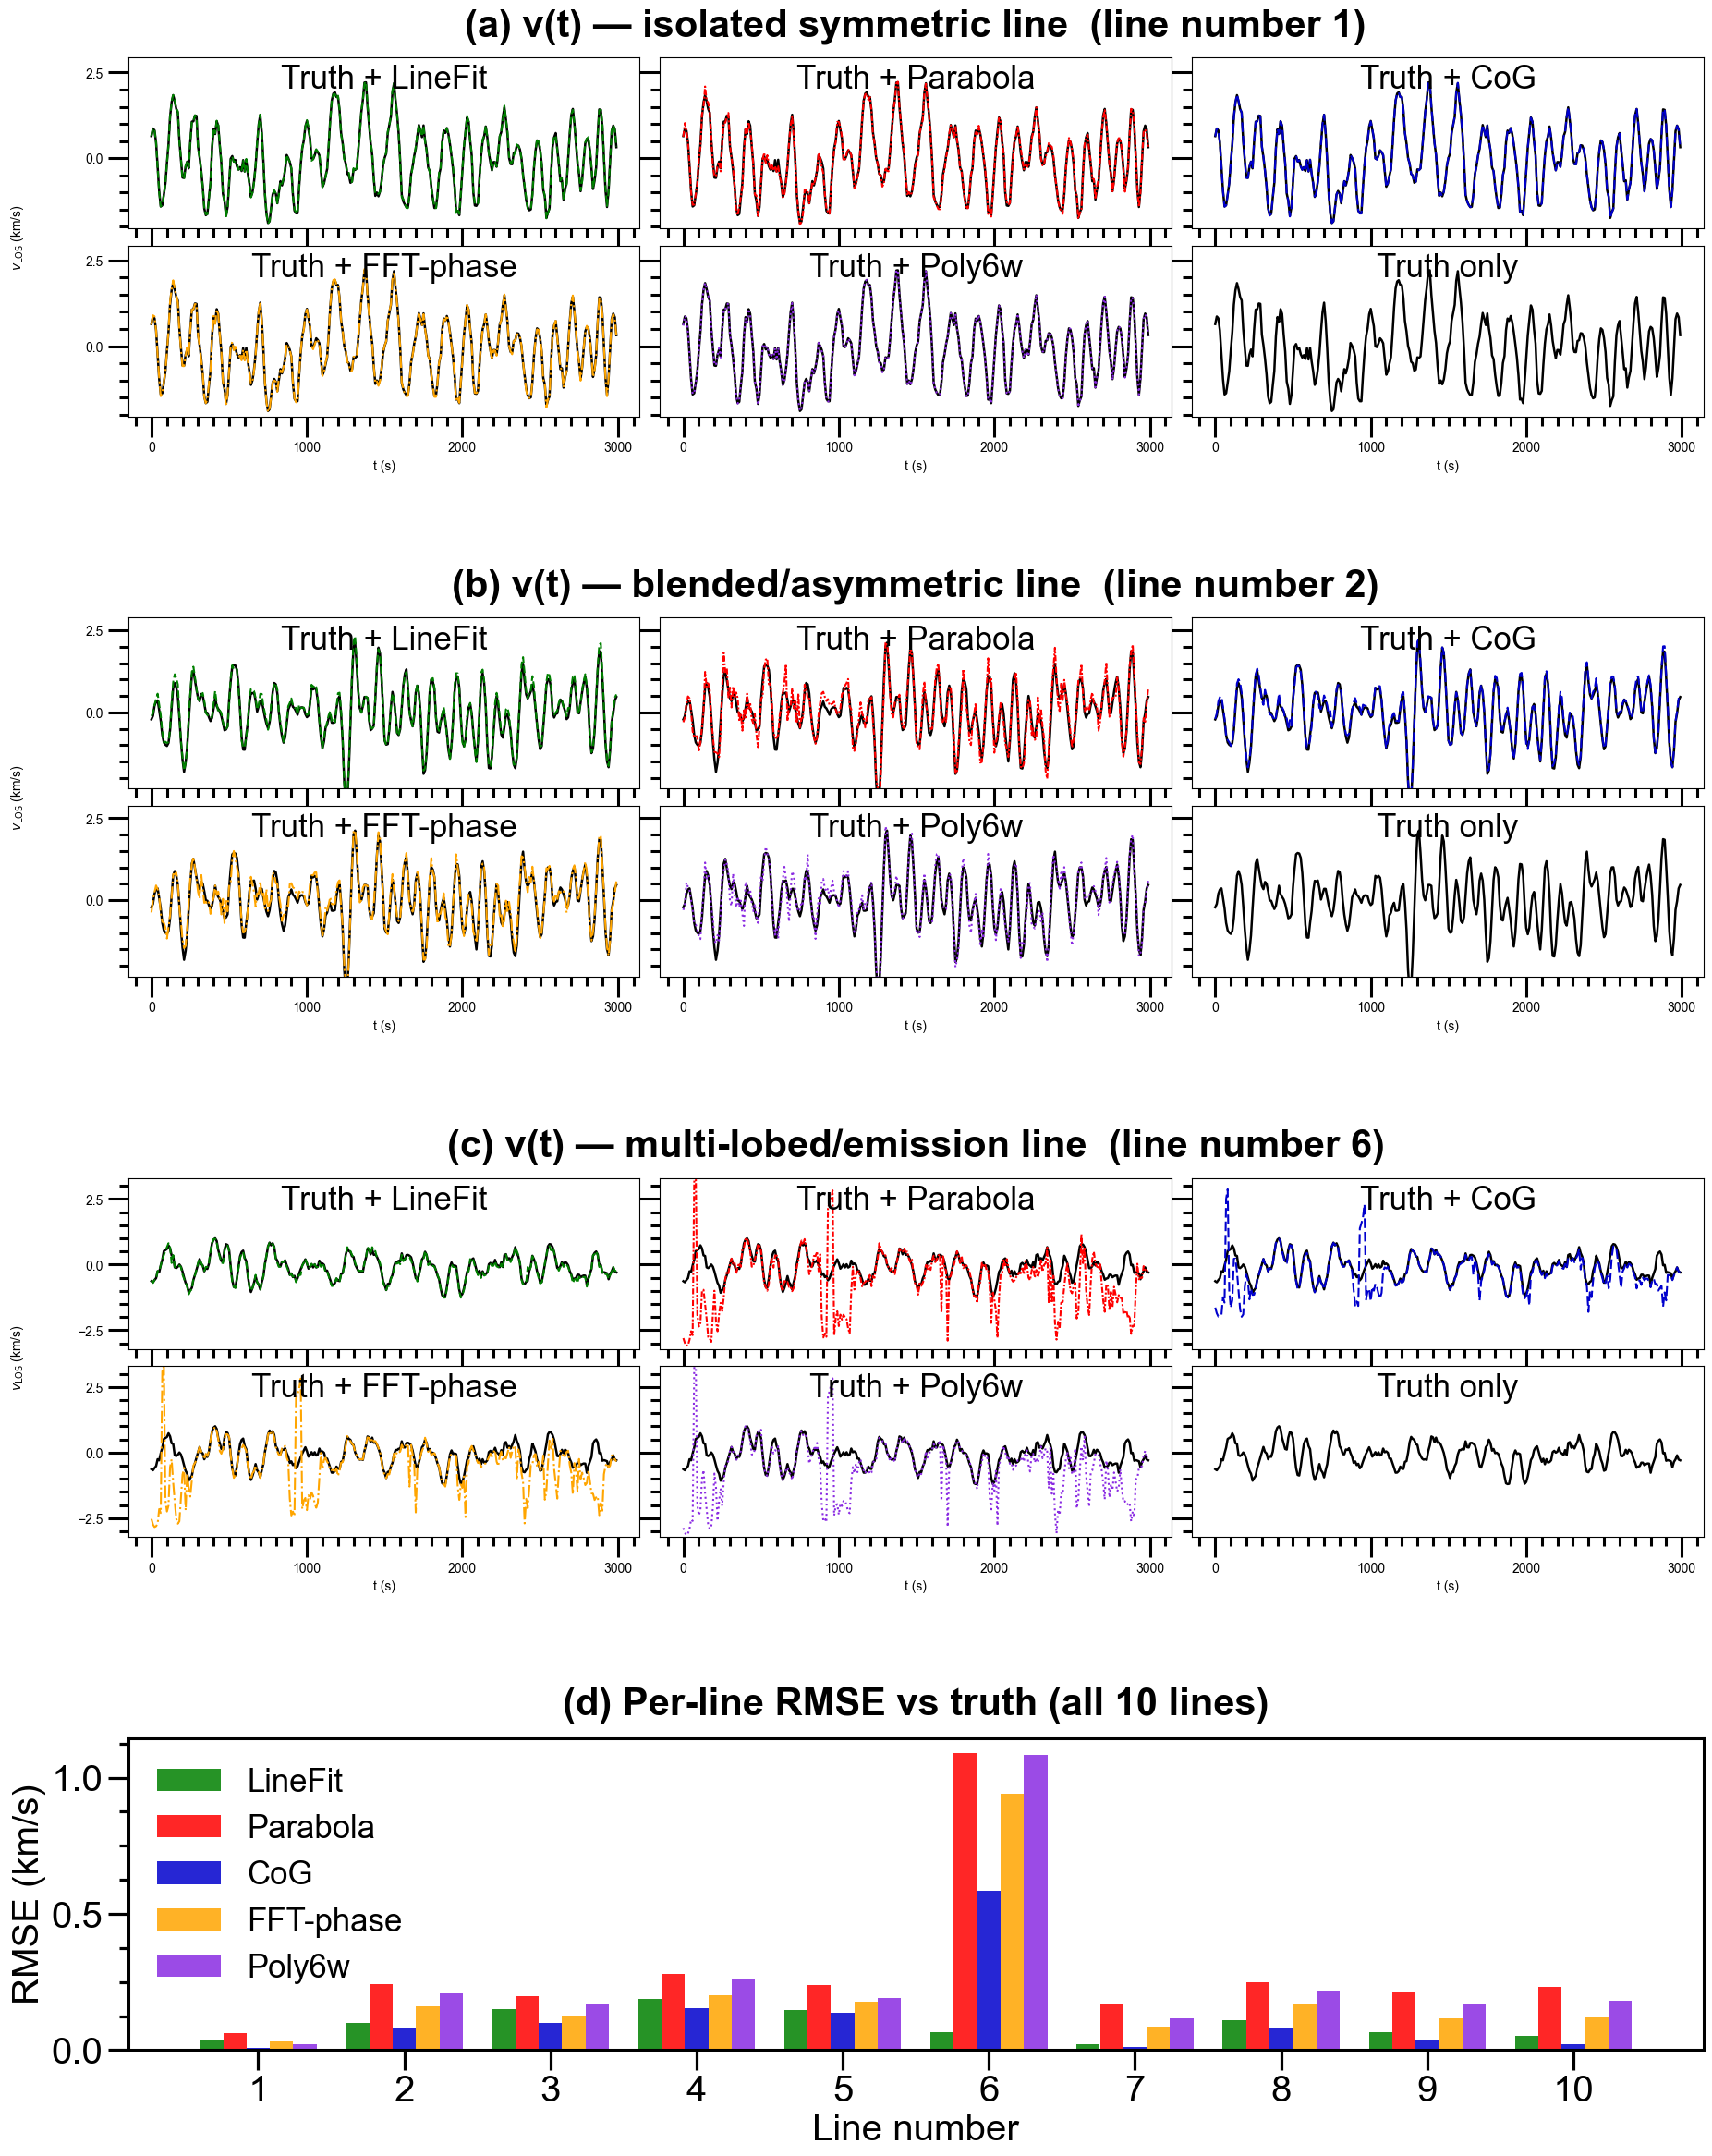

GPL Ghostscript 10.06.0 (2025-09-09)
Copyright (C) 2025 Artifex Software, Inc.  All rights reserved.
This software is supplied under the GNU AGPLv3 and comes with NO WARRANTY:
see the file COPYING for details.
Processing pages 1 through 1.
Page 1
PDF saved in CMYK format as 'Figures/Figure4_velocities_comparison.pdf'
Loaded cache: Files/Fig4_cache/fig4_vtimeseries
RUN_LINEFIT_TIMESERIES: True
Metric: RMSE


In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Figure 4 — Plot
=======================

Purpose
-------
Generate Figure 4 *exactly as used in the manuscript* from cached NumPy arrays.

Figure layout (paper)
---------------------
• 4 rows total
  - Rows (a), (b), (c): each row contains 6 mini-panels (2 × 3)
      Each mini-panel overlays the truth v(t) with ONE method (or truth-only)
  - Row (d): full-width grouped bars summarising per-line errors (RMSE/MAE)

Inputs
------
This script expects the cache products produced by “Figure 4 — Calculations”:

  Files/Fig4_cache/fig4_vtimeseries__t_s.npy
  Files/Fig4_cache/fig4_vtimeseries__lambda0_nm.npy
  Files/Fig4_cache/fig4_vtimeseries__v_true.npy
  Files/Fig4_cache/fig4_vtimeseries__v_linefit.npy
  Files/Fig4_cache/fig4_vtimeseries__v_parab.npy
  Files/Fig4_cache/fig4_vtimeseries__v_cog.npy
  Files/Fig4_cache/fig4_vtimeseries__v_fft.npy
  Files/Fig4_cache/fig4_vtimeseries__v_poly.npy
  Files/Fig4_cache/fig4_vtimeseries__meta.npz

Important: “LineFit” naming
---------------------------
In the manuscript the adaptive fitter is called **LineFit**. Therefore:
  • v_walsa → v_linefit
  • RUN_WALSA_TIMESERIES → RUN_LINEFIT_TIMESERIES

No changes to results or styling
--------------------------------
This script only:
  • updates paths to match the repository structure (Files/Fig4_cache/)
  • renames variables to “LineFit” for consistency with the paper
All calculations and plotting style remain unchanged.

Dependencies
------------
numpy, matplotlib, WaLSAtools (WaLSA_save_pdf)

Authors
-------
  WaLSA Team / Shahin Jafarzadeh (2026)
  https://WaLSA.team

License
-------
  Apache-2.0 license — see LICENSE file in the WaLSAlib repository.
  https://github.com/WaLSAteam/WaLSAlib

"""

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from WaLSAtools import WaLSAtools, WaLSA_save_pdf  # type: ignore

# =============================================================================
# CACHE SETTINGS (repo structure)
# =============================================================================
CACHE_DIR = os.path.join("Files", "Fig4_cache")
CACHE_TAG = "fig4_vtimeseries"

# =============================================================================
# Load cache
# =============================================================================
t_s        = np.load(os.path.join(CACHE_DIR, f"{CACHE_TAG}__t_s.npy"))
lambda0_nm = np.load(os.path.join(CACHE_DIR, f"{CACHE_TAG}__lambda0_nm.npy"))

v_true    = np.load(os.path.join(CACHE_DIR, f"{CACHE_TAG}__v_true.npy"))
v_linefit = np.load(os.path.join(CACHE_DIR, f"{CACHE_TAG}__v_linefit.npy"))
v_parab   = np.load(os.path.join(CACHE_DIR, f"{CACHE_TAG}__v_parab.npy"))
v_cog     = np.load(os.path.join(CACHE_DIR, f"{CACHE_TAG}__v_cog.npy"))
v_fft     = np.load(os.path.join(CACHE_DIR, f"{CACHE_TAG}__v_fft.npy"))
v_poly    = np.load(os.path.join(CACHE_DIR, f"{CACHE_TAG}__v_poly.npy"))

meta = np.load(os.path.join(CACHE_DIR, f"{CACHE_TAG}__meta.npz"), allow_pickle=True)

i_clean = int(meta["i_clean"])
i_asym  = int(meta["i_asym"])
i_comp  = int(meta["i_comp"])

if "RUN_LINEFIT_TIMESERIES" in meta.files:
    RUN_LINEFIT_TIMESERIES = bool(meta["RUN_LINEFIT_TIMESERIES"])
elif "RUN_WALSA_TIMESERIES" in meta.files:
    RUN_LINEFIT_TIMESERIES = bool(meta["RUN_WALSA_TIMESERIES"])  # legacy key
else:
    RUN_LINEFIT_TIMESERIES = True  # default assumption: LineFit is present in cache

nt, n_lines = v_true.shape

# =============================================================================
# Error metric (RMSE or MAE)
# =============================================================================
def rmse(a, b):
    m = np.isfinite(a) & np.isfinite(b)
    if np.count_nonzero(m) == 0:
        return np.nan
    return np.sqrt(np.mean((a[m] - b[m])**2))

def mae(a, b):
    m = np.isfinite(a) & np.isfinite(b)
    if np.count_nonzero(m) == 0:
        return np.nan
    return np.mean(np.abs(a[m] - b[m]))

USE_RMSE = True
err = rmse if USE_RMSE else mae
err_name = "RMSE" if USE_RMSE else "MAE"

err_parab   = np.array([err(v_parab[:, i],   v_true[:, i]) for i in range(n_lines)])
err_cog     = np.array([err(v_cog[:, i],     v_true[:, i]) for i in range(n_lines)])
err_fft     = np.array([err(v_fft[:, i],     v_true[:, i]) for i in range(n_lines)])
err_poly    = np.array([err(v_poly[:, i],    v_true[:, i]) for i in range(n_lines)])
err_linefit = np.array([err(v_linefit[:, i], v_true[:, i]) for i in range(n_lines)]) if RUN_LINEFIT_TIMESERIES else None

# =============================================================================
# Figure-wide style mapping from Figure 3
# =============================================================================
METHOD_STYLES = {
    "LineFit":   {"color": "green",      "linestyle": "--"},
    "Parabola":  {"color": "red",        "linestyle": (0, (3, 1, 1, 1))},
    "CoG":       {"color": "mediumblue", "linestyle": (0, (5, 2))},
    "FFT-phase": {"color": "orange",     "linestyle": "-."},
    "Poly6w":    {"color": "blueviolet", "linestyle": ":"},
    "Truth":     {"color": "black",      "linestyle": "-"},
}

# =============================================================================
# Outer Figure: 4 rows
# =============================================================================
fig = plt.figure(figsize=(22, 28))
gs_outer = fig.add_gridspec(4, 1, hspace=0.58, height_ratios=[1.15, 1.15, 1.15, 1.00])

# =============================================================================
# Helper to create one full row of 6 mini-panels
# =============================================================================
def make_row(subspec, i_line, row_title):
    # 2 rows x 3 columns for the 6 subpanels
    subgs = subspec.subgridspec(2, 3, wspace=0.04, hspace=0.10)

    panels = [
        ("Truth + LineFit",   "LineFit",   v_linefit if RUN_LINEFIT_TIMESERIES else None),
        ("Truth + Parabola",  "Parabola",  v_parab),
        ("Truth + CoG",       "CoG",       v_cog),
        ("Truth + FFT-phase", "FFT-phase", v_fft),
        ("Truth + Poly6w",    "Poly6w",    v_poly),
        ("Truth only",        None,        None),
    ]

    y_all = [v_true[:, i_line]]
    if RUN_LINEFIT_TIMESERIES and (v_linefit is not None):
        y_all.append(v_linefit[:, i_line])
    y_all += [v_parab[:, i_line], v_cog[:, i_line], v_fft[:, i_line], v_poly[:, i_line]]

    y_all = np.concatenate([yy[np.isfinite(yy)] for yy in y_all if yy is not None])
    if y_all.size > 0:
        ylo, yhi = np.percentile(y_all, [1, 99])
        pad = 0.08 * (yhi - ylo) if yhi > ylo else 1.0
        ylim = (ylo - pad, yhi + pad)
    else:
        ylim = (-1.0, 1.0)

    # extra headroom for inside titles
    yr = ylim[1] - ylim[0]
    ylim = (ylim[0], ylim[1] + 0.12 * yr)

    axes = []
    for j, (title, method_name, vmat) in enumerate(panels):
        r = j // 3
        c = j % 3

        ax = fig.add_subplot(subgs[r, c])
        axes.append(ax)

        # Truth
        ax.plot(
            t_s, v_true[:, i_line],
            color=METHOD_STYLES["Truth"]["color"],
            linestyle=METHOD_STYLES["Truth"]["linestyle"],
            lw=1.8,
        )

        # Method
        if method_name is not None:
            if (method_name == "LineFit") and (not RUN_LINEFIT_TIMESERIES or vmat is None):
                ax.text(0.04, 0.84, "LineFit not\ncomputed", transform=ax.transAxes)
            else:
                ax.plot(
                    t_s, vmat[:, i_line],
                    color=METHOD_STYLES[method_name]["color"],
                    linestyle=METHOD_STYLES[method_name]["linestyle"],
                    lw=1.5,
                )

        ax.set_ylim(*ylim)

        # subpanel title inside plot, top-center
        ax.text(
            0.5, 0.96, title,
            transform=ax.transAxes,
            ha="center", va="top", fontsize=25
        )

        ax.tick_params(axis="both", which="major", length=16, width=2.2)
        ax.tick_params(axis="both", which="minor", length=7, width=2.2)
        ax.xaxis.set_minor_locator(AutoMinorLocator(10))
        ax.yaxis.set_minor_locator(AutoMinorLocator(5))

        # keep y tick labels only for the left-most panels
        if c != 0:
            ax.set_yticklabels([])

        # show the y-axis title only once for the whole 2x3 block
        if r == 1 and c == 0:
            ax.set_ylabel(r"$v_{\rm LOS}$ (km/s)")
            ax.yaxis.set_label_coords(-0.20, 1.05)

        # x-label only on bottom row
        if r == 1:
            ax.set_xlabel("t (s)")
        else:
            ax.set_xticklabels([])

    # centered row title above the whole 2x3 block
    row_bbox_left  = axes[0].get_position()
    row_bbox_right = axes[2].get_position()
    x_center = 0.5 * (row_bbox_left.x0 + row_bbox_right.x1)
    y_top = row_bbox_left.y1 + 0.005

    fig.text(
        x_center, y_top,
        row_title + f"  (line number {i_line+1})",
        ha="center", va="bottom", fontsize=30, fontweight="bold"
    )

# =============================================================================
# Build rows (a), (b), (c)
# =============================================================================
make_row(gs_outer[0], 0, "(a) v(t) — isolated symmetric line")
make_row(gs_outer[1], 1, "(b) v(t) — blended/asymmetric line")
make_row(gs_outer[2], 5, "(c) v(t) — multi-lobed/emission line")

# =============================================================================
# (d) grouped bars by method for all lines (order/colors follow Figure 3)
# =============================================================================
plt.rcParams.update({
    'font.family': 'sans-serif',     # Use sans-serif fonts
    'font.sans-serif': 'Arial',      # Set Helvetica as the default sans-serif font
    'font.size': 30,                 # Global font size
    'axes.titlesize': 29,            # Title font size
    'axes.labelsize': 29,            # Axis label font size
    'xtick.labelsize': 29,           # X-axis tick label size
    'ytick.labelsize': 29,           # Y-axis tick label size
    'legend.fontsize': 29,           # Legend font size
    'figure.titlesize': 32,          # Figure title font size
    'axes.grid': False,              # Turn on grid by default
    'grid.alpha': 0.5,               # Grid transparency
    'grid.linestyle': '--',          # Grid line style
    'font.weight': 500,              # Make all fonts bold
    'axes.titleweight': 500,         # Make title font bold
    'axes.labelweight': 500          # Make axis labels bold
})

plt.rc('axes', linewidth=2.2)
plt.rc('lines', linewidth=1.5)

axD = fig.add_subplot(gs_outer[3, 0])

x = np.arange(n_lines) + 1  # line numbers starting from 1 for better readability
bw = 0.16

bar_series = []
if RUN_LINEFIT_TIMESERIES:
    bar_series.append(("LineFit", err_linefit))

bar_series += [
    ("Parabola",  err_parab),
    ("CoG",       err_cog),
    ("FFT-phase", err_fft),
    ("Poly6w",    err_poly),
]

# centre the bars nicely regardless of whether LineFit is present
nbar = len(bar_series)
offset_vals = (np.arange(nbar) - 0.5 * (nbar - 1)) * bw

for off, (name, values) in zip(offset_vals, bar_series):
    axD.bar(
        x + off,
        values,
        width=bw,
        label=name,
        color=METHOD_STYLES[name]["color"],
        alpha=0.85,
    )

axD.set_title(f"(d) Per-line {err_name} vs truth (all {n_lines} lines)", pad=18, fontsize=30, fontweight="bold")
axD.set_xlabel("Line number")
axD.set_ylabel(f"{err_name} (km/s)")
axD.set_xticks(x)
axD.tick_params(axis="both", which="major", length=16, width=2.3)
axD.tick_params(axis="both", which="minor", length=7, width=2.3)
axD.yaxis.set_minor_locator(AutoMinorLocator(4))
axD.legend(fontsize=25, loc="upper left", frameon=False)

plt.show()

# =============================================================================
# Save the figure as a single PDF (same style/output as before)
# =============================================================================
pdf_path = 'Figures/Figure4_velocities_comparison.pdf'
WaLSA_save_pdf(fig, pdf_path, color_mode='CMYK', dpi=300, bbox_inches='tight', pad_inches=0.1)

print("Loaded cache:", os.path.join(CACHE_DIR, CACHE_TAG))
print("RUN_LINEFIT_TIMESERIES:", RUN_LINEFIT_TIMESERIES)
print("Metric:", err_name)